Connected to Python 3.12.6

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM

In [ ]:
df = pd.read_excel('Brasil_data.xlsx')

df['Date'] = pd.to_datetime(df['Date'], format='%m/%Y')
df = df.set_index('Date')
df = df.sort_index()
df.index.freq = 'MS'

df = df[['RER', 'Reserva_real', 'Commod_real']]
df['RER'] = df['RER'].str.replace(',', '.').astype(float)

print(df.describe().round(2))

          RER  Reserva_real   Commod_real
count  228.00  2.280000e+02  2.280000e+02
mean   102.02  3.075825e+11  8.514657e+09
std     20.04  1.624884e+11  3.983280e+09
min     71.76  8.928958e+10  2.249979e+09
25%     87.37  1.150961e+11  5.502883e+09
50%     97.88  3.673153e+11  8.021292e+09
75%    111.67  4.365147e+11  1.128690e+10
max    171.03  5.505516e+11  1.950534e+10


In [ ]:
for col in df.columns:
    adf = adfuller(df[col], autolag='AIC')
    kpss_stat, kpss_p, _, _ = kpss(df[col], regression='c', nlags='auto')
    print(f"{col} — ADF p = {adf[1]:.4f} | KPSS p = {kpss_p:.4f}")


RER — ADF p = 0.2678 | KPSS p = 0.0100
Reserva_real — ADF p = 0.4420 | KPSS p = 0.0100
Commod_real — ADF p = 0.4208 | KPSS p = 0.0100


<ipython-input-3-e0c5985fbd82>:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(df[col], regression='c', nlags='auto')
<ipython-input-3-e0c5985fbd82>:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(df[col], regression='c', nlags='auto')
<ipython-input-3-e0c5985fbd82>:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(df[col], regression='c', nlags='auto')


In [ ]:
lag_test = VAR(df)
lag_selection = lag_test.select_order(maxlags=12)
print(lag_selection.summary())

p = max(2, lag_selection.selected_orders['bic'])
print(f"Lag escolhido: {p}")


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        99.84       99.88   2.284e+43       99.86
1        90.27      90.46*   1.600e+39       90.35
2        90.14       90.47   1.404e+39      90.27*
3        90.14       90.61   1.407e+39       90.33
4        90.11       90.72   1.357e+39       90.35
5        90.14       90.89   1.402e+39       90.44
6        90.10       90.99   1.350e+39       90.46
7        90.02       91.05   1.243e+39       90.43
8        90.08       91.25   1.322e+39       90.55
9       90.00*       91.31  1.226e+39*       90.53
10       90.03       91.48   1.265e+39       90.62
11       90.04       91.64   1.286e+39       90.69
12       90.04       91.78   1.287e+39       90.74
--------------------------------------------------
Lag escolhido: 2


In [ ]:
johansen = coint_johansen(df, det_order=0, k_ar_diff=p-1)
print(johansen.lr1)
print(johansen.cvt)

[53.19951343 19.09847561  0.93143715]
[[27.0669 29.7961 35.4628]
 [13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]


In [ ]:
vecm = VECM(df, k_ar_diff=p-1, coint_rank=1, deterministic='co')
vecm_fit = vecm.fit()
print(vecm_fit.summary())

 Det. terms outside the coint. relation & lagged endog. parameters for equation RER
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.2143      0.453     -0.473      0.636      -1.101       0.673
L1.RER              0.2706      0.065      4.179      0.000       0.144       0.398
L1.Reserva_real   3.58e-11   3.65e-11      0.980      0.327   -3.58e-11    1.07e-10
L1.Commod_real  -1.853e-10   1.89e-10     -0.979      0.328   -5.57e-10    1.86e-10
Det. terms outside the coint. relation & lagged endog. parameters for equation Reserva_real
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const           -5.342e+08   7.71e+08     -0.693      0.488   -2.04e+09    9.76e+08
L1.RER          -1.791e+08    1.1e+08     -1.624      0.104   -3.95e

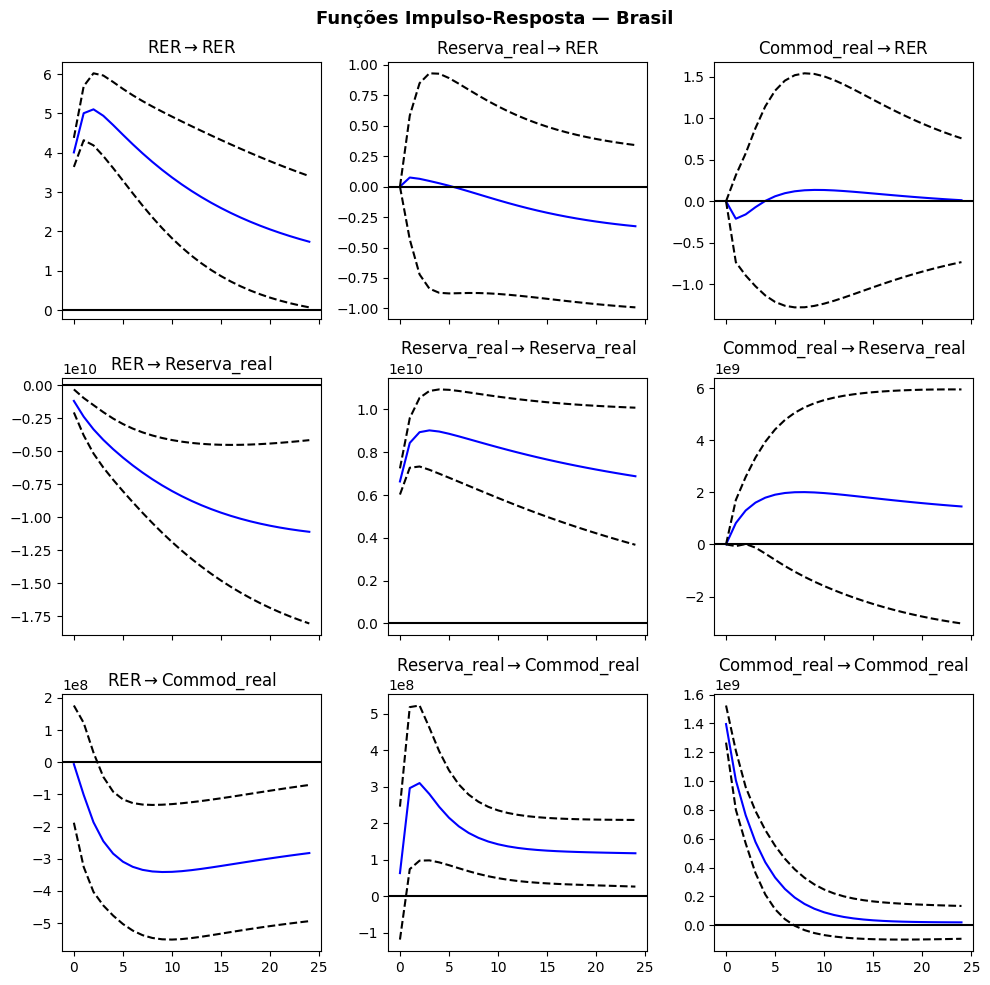

FEVD for RER
           RER  Reserva_real  Commod_real
0     1.000000      0.000000     0.000000
1     0.998793      0.000135     0.001072
2     0.998828      0.000143     0.001028
3     0.999062      0.000129     0.000809
4     0.999238      0.000110     0.000652
5     0.999323      0.000094     0.000582
6     0.999338      0.000085     0.000577
7     0.999305      0.000086     0.000609
8     0.999240      0.000101     0.000659
9     0.999154      0.000133     0.000713
10    0.999051      0.000186     0.000763
11    0.998932      0.000261     0.000807
12    0.998800      0.000358     0.000842
13    0.998652      0.000480     0.000869
14    0.998488      0.000625     0.000887
15    0.998308      0.000794     0.000899
16    0.998110      0.000985     0.000905
17    0.997894      0.001200     0.000906
18    0.997661      0.001435     0.000904
19    0.997411      0.001690     0.000899
20    0.997143      0.001965     0.000892
21    0.996860      0.002256     0.000884
22    0.996560      0

In [ ]:
var_model = VAR(df)
var_fit = var_model.fit(p)

irf = var_fit.irf(24)
irf.plot(orth=True, signif=0.05)
plt.suptitle('Funções Impulso-Resposta — Brasil', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('irf.png', dpi=150, bbox_inches='tight')
plt.show()

fevd = var_fit.fevd(24)
print(fevd.summary())